# Examen de Primer Bimestre - ICCD753 Recuperación de Información 2026-A
**Estudiante:** Miguel Muzo  
**Archivo:** `MuzoMiguel_ex1bim_ir26a.ipynb`  
**Corpus:** Rotten Tomatoes Movies and Critic Reviews Dataset  
**Modelo de embeddings:** Word2Vec Google News 300 (Gensim)  
**Recuperación:** Similitud coseno sobre representaciones vectoriales  

---

## Dependencias

Las siguientes librerías deben estar instaladas en el entorno:

```bash
pip install gensim scikit-learn pandas numpy matplotlib nltk
```

El modelo `word2vec-google-news-300` se descarga automáticamente con `gensim.downloader` si no está en caché local (`~/gensim-data/`). Pesa ~1.7 GB y solo se descarga una vez.

---
## Dataset

[rotten-tomatoes-movies-and-critic-reviews-dataset](https://www.kaggle.com/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset/data)


In [1]:
import re
import os
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

import gensim.downloader as api
from gensim.models import KeyedVectors

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

---
## 1. Carga del Corpus

El corpus utilizado es el dataset **Rotten Tomatoes Movies and Critic Reviews**.  

In [2]:
# Carga de ambos datasets
df_movies  = pd.read_csv("rotten_tomatoes_movies.csv")
df_reviews = pd.read_csv("rotten_tomatoes_critic_reviews.csv")

print(f"Movies  : {df_movies.shape[0]:,} filas x {df_movies.shape[1]} columnas")
print(f"Reviews : {df_reviews.shape[0]:,} filas x {df_reviews.shape[1]} columnas")
print("Columnas movies :", df_movies.columns.tolist())
print("Columnas reviews:", df_reviews.columns.tolist())

Movies  : 17,712 filas x 22 columnas
Reviews : 1,130,017 filas x 8 columnas
Columnas movies : ['rotten_tomatoes_link', 'movie_title', 'movie_info', 'critics_consensus', 'content_rating', 'genres', 'directors', 'authors', 'actors', 'original_release_date', 'streaming_release_date', 'runtime', 'production_company', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_status', 'audience_rating', 'audience_count', 'tomatometer_top_critics_count', 'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count']
Columnas reviews: ['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name', 'review_type', 'review_score', 'review_date', 'review_content']


### 1.1 Selección de campos textuales

Cada documento es una reseña de crítico, enriquecida con el título de la película mediante join.

| Campo | Origen | Rol |
|-------|--------|-----|
| `movie_title` | rotten_tomatoes_movies.csv | Título de la película |
| `critic_name` | rotten_tomatoes_critic_reviews.csv | Autor de la reseña |
| `review_content` | rotten_tomatoes_critic_reviews.csv | Contenido de la crítica |

Se descartan las reseñas con `review_content` vacío ya que no aportan información textual para el embedding.

In [3]:
# Join: enriquecer reseñas con movie_title desde movies
df_corpus = df_reviews.merge(
    df_movies[["rotten_tomatoes_link", "movie_title"]],
    on="rotten_tomatoes_link",
    how="left"
)

# Filtrar reseñas sin contenido textual
df_corpus = df_corpus[df_corpus["review_content"].notna()].reset_index(drop=True)

# Construir texto del documento: título + autor + contenido de la crítica
df_corpus["texto_raw"] = (
    df_corpus["movie_title"].fillna("") + " " +
    df_corpus["critic_name"].fillna("") + " " +
    df_corpus["review_content"].fillna("")
).str.strip()

print(f"Documentos totales (reseñas con contenido): {len(df_corpus):,}")
df_corpus[["rotten_tomatoes_link", "movie_title", "critic_name", "review_content"]].head(10)

Documentos totales (reseñas con contenido): 1,064,211


,rotten_tomatoes_link,movie_title,critic_name,review_content
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,Andrew L. Urban,A fantasy adventure that fuses Greek mythology...
1,m/0814255,Percy Jackson & the Olympians: The Lightning T...,Louise Keller,"Uma Thurman as Medusa, the gorgon with a coiff..."
2,m/0814255,Percy Jackson & the Olympians: The Lightning T...,NaN,With a top-notch cast and dazzling special eff...
3,m/0814255,Percy Jackson & the Olympians: The Lightning T...,Ben McEachen,Whether audiences will get behind The Lightnin...
4,m/0814255,Percy Jackson & the Olympians: The Lightning T...,Ethan Alter,What's really lacking in The Lightning Thief i...
5,m/0814255,Percy Jackson & the Olympians: The Lightning T...,David Germain,It's more a list of ingredients than a movie-m...
6,m/0814255,Percy Jackson & the Olympians: The Lightning T...,Nick Schager,Harry Potter knockoffs don't come more transpa...
7,m/0814255,Percy Jackson & the Olympians: The Lightning T...,Bill Goodykoontz,"Percy Jackson isn't a great movie, but it's a ..."
8,m/0814255,Percy Jackson & the Olympians: The Lightning T...,Jordan Hoffman,"Fun, brisk and imaginative"
9,m/0814255,Percy Jackson & the Olympians: The Lightning T...,Jim Schembri,"Crammed with dragons, set-destroying fights an..."


---
## 2. Preprocesamiento
  1. Conversión a minúsculas
  2. Eliminación de signos de puntuación
  3. Eliminación de espacios redundantes
  4. Eliminación de stopwords (inglés)

In [4]:
STOPWORDS_EN = set(stopwords.words("english"))

def preprocess(texto: str) -> list[str]:
    # 1. Minúsculas
    texto = texto.lower()
    # 2. Eliminar puntuación
    texto = texto.translate(str.maketrans("", "", string.punctuation))
    # 3. Eliminar espacios redundantes
    texto = re.sub(r"\s+", " ", texto).strip()
    # 4. Tokenizar y eliminar stopwords
    tokens = [t for t in texto.split() if t not in STOPWORDS_EN and len(t) > 1]
    return tokens

In [5]:
# Aplicacion del procesamiento del corpus completo
df_corpus["tokens"] = df_corpus["texto_raw"].apply(preprocess)

# Estadísticas
longitudes = df_corpus["tokens"].apply(len)

print(f"Preprocesamiento completado: {len(df_corpus):,} documentos")
print()
print("Ejemplo documento preprocesado:")
print(f"  Título  : {df_corpus.iloc[0]['movie_title']}")
print(f"  Autor   : {df_corpus.iloc[0]['critic_name']}")
print(f"  Tokens  : {df_corpus.iloc[0]['tokens'][:20]} ...")

Preprocesamiento completado: 1,064,211 documentos

Ejemplo documento preprocesado:
  Título  : Percy Jackson & the Olympians: The Lightning Thief
  Autor   : Andrew L. Urban
  Tokens  : ['percy', 'jackson', 'olympians', 'lightning', 'thief', 'andrew', 'urban', 'fantasy', 'adventure', 'fuses', 'greek', 'mythology', 'contemporary', 'american', 'places', 'values', 'anyone', 'around', '15', 'give'] ...


---
## 3. Generación de Embeddings

**Modelo:** `word2vec-google-news-300`

In [6]:
model_embedding = api.load("word2vec-google-news-300")  # 0 word2vec-google-news-300

In [7]:
def embeddings_docs(tokens: list[str], modelo: KeyedVectors) -> np.ndarray:
    """
    Genera embedding de un documento promediando los vectores
    de los tokens presentes en el vocabulario del modelo.
    Retorna vector de ceros si ningún token está en el vocabulario.
    """
    vecs = [modelo[t] for t in tokens if t in modelo]
    if not vecs:
        return np.zeros(modelo.vector_size)
    return np.mean(vecs, axis=0)

In [8]:
print(f"Generando embeddings para {len(df_corpus):,} documentos...")
doc_embeddings = np.array([
    embeddings_docs(tokens, model_embedding)
    for tokens in df_corpus["tokens"]
])
print(f"\nMatriz de embeddings: {doc_embeddings.shape}  (documentos × dimensiones)")
sin_rep = (np.linalg.norm(doc_embeddings, axis=1) == 0).sum()
print(f"Documentos sin representación (vector cero): {sin_rep}")

Generando embeddings para 1,064,211 documentos...

Matriz de embeddings: (1064211, 300)  (documentos × dimensiones)
Documentos sin representación (vector cero): 2


---
## 4. Procesamiento de Consultas

In [9]:
def process_query(query: str, modelo: KeyedVectors):
    """
    Preprocesa la consulta y genera su embedding.
    Usa el mismo pipeline que los documentos para garantizar consistencia.
    """
    tokens = preprocess(query)
    return embeddings_docs(tokens, modelo)

---
## 5. Recuperación — Similitud Coseno
Salida por consulta: `Ranking | ID documento | Título película | Fragmento de texto | Similitud`

Recuperar los k documentos más relevantes para una consulta.
Proceso:
  1. Preprocesar consulta
  2. Generar embedding de la consulta
  3. Calcular similitud coseno con todos los documentos
  4. Ordenar de mayor a menor similitud
  5. Retornar DataFrame con Ranking, ID, Título, Fragmento, Similitud

In [10]:
def retrieve(query: str, k: int = 5):
    # 1-2. Embedding de la consulta
    q_vec = process_query(query, model_embedding).reshape(1, -1)

    # 3. Similitud coseno contra toda la matriz
    scores = cosine_similarity(q_vec, doc_embeddings).flatten()

    # 4. Top-k índices ordenados
    top_idx = scores.argsort()[::-1][:k]

    # 5. Construir resultado
    rows = []
    for rank, idx in enumerate(top_idx, start=1):
        doc = df_corpus.iloc[idx]
        rows.append({
            "Ranking"          : rank,
            "ID Documento"     : f"{doc['rotten_tomatoes_link']}#{idx}",
            "Título Película"  : doc["movie_title"],
            "Autor Crítica"    : doc["critic_name"],
            "Fragmento"        : str(doc["review_content"])[:200],
            "Similitud"        : round(float(scores[idx]), 4)
        })

    return pd.DataFrame(rows)

---
## 6. Benchmark de Consultas

In [11]:
TOP_K = 10

QUERIES = {
    "Q1": "science fiction movie with advanced technology",
    "Q2": "romantic story with emotional relationships",
    "Q3": "action movie with intense fight scenes",
    "Q4": "horror film that creates fear and suspense",
    "Q5": "visually impressive movie with weak storyline",
    "Q6": "emotionally moving performance by the lead actor",
    "Q7": "predictable plot but entertaining experience",
    "Q8": "movie praised by critics but unpopular with audiences",
}

In [12]:
# Q1 — science fiction movie with advanced technology
print(f"=== Q1: {QUERIES['Q1']} ===")
r_q1 = retrieve(QUERIES["Q1"], k=TOP_K)
display(r_q1)

=== Q1: science fiction movie with advanced technology ===


,Ranking,ID Documento,Título Película,Autor Crítica,Fragmento,Similitud
0,1,m/anya_2019#128169,Anya,M. Faust,Science fiction with an emphasis on the science,0.7761
1,2,m/the_osiris_child_science_fiction_volume_one#...,The Osiris Child: Science Fiction Volume One,Germain Lussier,It's a movie fans of nostalgic science fiction...,0.7648
2,3,m/i_robot#408948,"I, Robot",Jeffrey Westhoff,"I, Robot succeeds where other movies that blen...",0.7621
3,4,m/outland#593916,Outland,Dragan Antulov,Exciting science fiction.,0.7562
4,5,m/gravity_2013#362661,Gravity,Sherilyn Connelly,One of the best science fiction movies in years.,0.7409
5,6,m/rollerball#690147,Rollerball,Dragan Antulov,One of the most powerful science fiction films...,0.7381
6,7,m/rollerball#690146,Rollerball,Dragan Antulov,One of the most powerful science fiction films...,0.7381
7,8,m/the_osiris_child_science_fiction_volume_one#...,The Osiris Child: Science Fiction Volume One,Dov Kornits,The Osiris Child: Science Fiction Volume One i...,0.7293
8,9,m/terminator#858066,The Terminator,Dragan Antulov,[An] excellent piece of science fiction cinema.,0.7277
9,10,m/1112951-time_machine#42206,The Time Machine,Tony Toscano,A very average science fiction film.,0.7168


In [13]:
# Q2 — romantic story with emotional relationships
print(f"=== Q2: {QUERIES['Q2']} ===")
r_q2 = retrieve(QUERIES["Q2"], k=TOP_K)
display(r_q2)

=== Q2: romantic story with emotional relationships ===


,Ranking,ID Documento,Título Película,Autor Crítica,Fragmento,Similitud
0,1,m/marriage_story_2019#520484,Marriage Story,Josh Martin,An intimate tale of a relationship's collapse ...,0.7685
1,2,m/life-of-pi#485464,Life of Pi,Betsy Bozdech,"Beautiful, emotional, intense story of faith a...",0.7594
2,3,m/love_story#503570,Love Story,Tim Dirks,"Love Story (1970) is a sentimental, romantic t...",0.7505
3,4,m/soulmate_2016#789887,SoulMate,Edmund Lee,Derek Tsang's film transcends its potentially ...,0.7483
4,5,m/soulmate_2016#789886,SoulMate,Edmund Lee,Derek Tsang's film transcends its potentially ...,0.7483
5,6,m/marriage_story_2019#520425,Marriage Story,Jazz Tangcay,Marriage Story is a timeless look at relations...,0.7466
6,7,m/the_farewell_party#892663,The Farewell Party,Tirdad Derakhshani,"For all its talk of death, The Farewell Party,...",0.7425
7,8,m/her#384118,Her,Larushka Ivan-Zadeh,"It's still an inspired, playful, erotic and ge...",0.7412
8,9,m/someone_great#782704,Someone Great,Marianne Eloise,"A nuanced, perfectly-soundtracked comedy about...",0.7401
9,10,m/someone_great#782705,Someone Great,Marianne Eloise,"A nuanced, perfectly-soundtracked comedy about...",0.7401


In [14]:
# Q3 — action movie with intense fight scenes
print(f"=== Q3: {QUERIES['Q3']} ===")
r_q3 = retrieve(QUERIES["Q3"], k=TOP_K)
display(r_q3)

=== Q3: action movie with intense fight scenes ===


,Ranking,ID Documento,Título Película,Autor Crítica,Fragmento,Similitud
0,1,m/now_you_see_me#578906,Now You See Me,S. Jhoanna Robledo,Teen-appealing heist movie has a few brutal fi...,0.7957
1,2,m/the_hurt_locker#914059,The Hurt Locker,Robert Roten,This is not just a character study. This film ...,0.7856
2,3,m/1212910-warrior#69144,Warrior,Peter Rainer,"O'Connor films the fight scenes, and the fight...",0.7789
3,4,m/children_of_men#220503,Children of Men,Micheal Compton,"A rare kind of film -- thought-provoking, but ...",0.7731
4,5,m/the_raid_2#947887,The Raid 2,Da'John Henderson,The action scenes in this movie are so goddamn...,0.7677
5,6,m/bourne_ultimatum#184915,The Bourne Ultimatum,Nell Minow,This movie has no pretence of being about anyt...,0.7622
6,7,m/collateral#233384,Collateral,Mike McGranaghan,"The movie is intense, not for the scenes of ac...",0.7516
7,8,m/now_you_see_me_2#579107,Now You See Me 2,S. Jhoanna Robledo,"Slick, charming sequel has similarly intense f...",0.7469
8,9,m/mongol#546421,Mongol,John Hartl,Bodrov's movie is most likely to be remembered...,0.7458
9,10,m/daredevil#251956,Daredevil,Collin Souter,A rare action movie that suffers when it has a...,0.7438


In [15]:
# Q4 — horror film that creates fear and suspense
print(f"=== Q4: {QUERIES['Q4']} ===")
r_q4 = retrieve(QUERIES["Q4"], k=TOP_K)
display(r_q4)

=== Q4: horror film that creates fear and suspense ===


,Ranking,ID Documento,Título Película,Autor Crítica,Fragmento,Similitud
0,1,m/annabelle_creation#124137,Annabelle: Creation,John Hanlon,A well-crafted horror film that relies on tens...,0.7999
1,2,m/amityville_horror#119424,The Amityville Horror,Greg Maki,It's come to this: a horror movie devoid of sc...,0.7952
2,3,m/thriller_2018#979715,Thriller,Sezín Koehler,"All in all, Thriller is a fun horror film with...",0.7874
3,4,m/1br#75555,1BR,Rich Cline,"...as the narrative develops, the film becomes...",0.7850
4,5,m/amityville_horror#119459,The Amityville Horror,Joshua Starnes,"A remake of the 1979 film, The Amityville Horr...",0.7777
5,6,m/panic_room#598317,Panic Room,Geoff Pevere,It feels less like a suspense movie than a vid...,0.7774
6,7,m/brightburn#192399,Brightburn,Ben Rolph,Brightburn takes time to build atmosphere and ...,0.7725
7,8,m/descent#264948,The Descent,Dave White,It's just what you want in a horror film -- st...,0.7666
8,9,m/mist#543849,The Mist,Cherryl Dawson and Leigh Ann Palone,"It's not the next horror classic, but it is th...",0.7658
9,10,m/jeepers_creepers_2#439989,Jeepers Creepers 2,Jon Niccum,Offers little of the foreboding suspense that ...,0.7634


In [16]:
# Q5 — visually impressive movie with weak storyline
print(f"=== Q5: {QUERIES['Q5']} ===")
r_q5 = retrieve(QUERIES["Q5"], k=TOP_K)
display(r_q5)

=== Q5: visually impressive movie with weak storyline ===


,Ranking,ID Documento,Título Película,Autor Crítica,Fragmento,Similitud
0,1,m/pleasantville#616227,Pleasantville,Marjorie Baumgarten,The movie's simplistic storyline does not matc...,0.7816
1,2,m/promare#633627,Promare,Toussaint Egan,"Promare is a visually stunning, narratively an...",0.7812
2,3,m/promare#633624,Promare,Toussaint Egan,"Promare is a visually stunning, narratively an...",0.7812
3,4,m/everest_2015#302462,Everest,Rich Cline,With visually stunning imagery and a solid A-l...,0.7802
4,5,m/pompeii_2013#618366,Pompeii,Nell Minow,"The special effects, especially in 3D, are imp...",0.7797
5,6,m/turbo_2013#998087,Turbo,Jennifer Tate,A perfectly enjoyable and often funny animatio...,0.7633
6,7,m/julien_donkeyboy#449060,Julien Donkey-Boy,Christabel Padmore,It's disappointing that this film doesn't real...,0.7630
7,8,m/intacto#425601,Intacto,Harvey S. Karten,Intriguing premise and nice visuals but a stor...,0.7612
8,9,m/incredibles_2#420338,Incredibles 2,Sameen Amer,The movie is well-executed and clearly made wi...,0.7610
9,10,m/1079818-anastasia#31936,Anastasia,Robert Roten,"While the movie is visually stunning, the char...",0.7608


In [17]:
# Q6 — emotionally moving performance by the lead actor
print(f"=== Q6: {QUERIES['Q6']} ===")
r_q6 = retrieve(QUERIES["Q6"], k=TOP_K)
display(r_q6)

=== Q6: emotionally moving performance by the lead actor ===


,Ranking,ID Documento,Título Película,Autor Crítica,Fragmento,Similitud
0,1,m/menashe#531940,Menashe,Mark Demetrius,"Menashe Lustig's performance here is strong, i...",0.6821
1,2,m/never_let_me_go_2010#568360,Never Let Me Go,Annette Basile,"Driven by terrific lead performances, this ach...",0.6808
2,3,m/1194949-wolfman#59915,The Wolfman,Jules Brenner,A more emotionally expressive actor might have...,0.6688
3,4,m/reign_over_me#664487,Reign Over Me,Jeff Vice,While Sandler's performance is surprisingly su...,0.6627
4,5,m/reign_over_me#664530,Reign Over Me,Jeff Vice,While Sandler's performance is surprisingly su...,0.6627
5,6,m/the_end_of_the_tour_2015#890305,The End Of The Tour,Rafer Guzman,More intellectually than emotionally compellin...,0.6620
6,7,m/greenberg#365176,Greenberg,Kyle Smith,To really pull off Greenberg would require a l...,0.6589
7,8,m/that_evening_sun#860953,That Evening Sun,Marjorie Baumgarten,As lovely as it is to see the veteran actor Ho...,0.6577
8,9,m/one_false_move#587451,One False Move,Mark Salisbury,Emotionally complex thriller with riveting per...,0.6562
9,10,m/nowhere_boy#579247,Nowhere Boy,Alistair Harkness,"[A] moving, emotionally direct biopic.",0.6549


In [18]:
# Q7 — predictable plot but entertaining experience
print(f"=== Q7: {QUERIES['Q7']} ===")
r_q7 = retrieve(QUERIES["Q7"], k=TOP_K)
display(r_q7)

=== Q7: predictable plot but entertaining experience ===


,Ranking,ID Documento,Título Película,Autor Crítica,Fragmento,Similitud
0,1,m/forces_of_nature#328744,Forces of Nature,Dragan Antulov,For the most part this film is not particularl...,0.7947
1,2,m/serenity_2019#730938,Serenity,Rafer Guzman,"A potentially enjoyable B movie, but the absur...",0.7473
2,3,m/serenity_2019#730890,Serenity,Rafer Guzman,"A potentially enjoyable B movie, but the absur...",0.7473
3,4,m/zootopia#1063985,Zootopia,Soren Andersen,Combining a surprisingly sophisticated conspir...,0.7449
4,5,m/skyscraper_2018#768448,Skyscraper,Robert Roten,"While the plot is predictable, there are a few...",0.7379
5,6,m/skyscraper_2018#768437,Skyscraper,Robert Roten,"While the plot is predictable, there are a few...",0.7379
6,7,m/+_one_2019#616431,NaN,Carla Hay,Plus One is as predictable as they come for ro...,0.7283
7,8,m/non_stop_2013#575817,Non-Stop,Matthew Turner,Thanks to a high dose of action and some plot ...,0.7280
8,9,m/allied#111240,Allied,Tony Medley,Despite all the plot holes and the flimsy prem...,0.7248
9,10,m/1070992-primal_fear#30064,Primal Fear,John J. Puccio,"The plot is engaging, the cast is exceptional,...",0.7245


In [19]:
# Q8 — movie praised by critics but unpopular with audiences
print(f"=== Q8: {QUERIES['Q8']} ===")
r_q8 = retrieve(QUERIES["Q8"], k=TOP_K)
display(r_q8)

=== Q8: movie praised by critics but unpopular with audiences ===


,Ranking,ID Documento,Título Película,Autor Crítica,Fragmento,Similitud
0,1,m/faces#307801,Faces,Matt Brunson,"Along with A Woman Under the Influence, Cassav...",0.7189
1,2,m/ice_storm#411466,The Ice Storm,Urban Cinefile Critics,An intelligent film that will appeal to though...,0.6996
2,3,m/1141102-are_we_there_yet#47823,Are We There Yet?,Vince Koehler,Several of my grand kids were with me at a rec...,0.6940
3,4,m/fight_club#317614,Fight Club,Marc Savlov,"An incendiary, psychotic film surely guarantee...",0.6901
4,5,m/jumper#450129,Jumper,John Beifuss,It's easy to see why audiences have embraced t...,0.6900
5,6,m/the_assassin_2015#868553,The Assassin,Alistair Ryder,The Assassin feels like a stereotype of a movi...,0.6810
6,7,m/1159169-for_your_consideration#53176,For Your Consideration,Urban Cinefile Critics,"Funny, biting, cutting and satirical %u2026 bu...",0.6806
7,8,m/you_dont_nomi#1057937,You Don't Nomi,Katie Hogan,The movie is a powerful and unforgettable exam...,0.6793
8,9,m/statement#820910,The Statement,Mark Keizer,The film's worthwhile subject matter and behin...,0.6698
9,10,m/statement#820922,The Statement,Mark Keizer,The film's worthwhile subject matter and behin...,0.6698


---
## 7. Tabla Resumen General

Mejor resultado (Top-1) de cada consulta: `Consulta | Documento Top-1 | Título película | Similitud`

In [20]:
resultados = {"Q1": r_q1, "Q2": r_q2, "Q3": r_q3, "Q4": r_q4,
              "Q5": r_q5, "Q6": r_q6, "Q7": r_q7, "Q8": r_q8}

resumen = []
for qid, df_res in resultados.items():
    top1 = df_res.iloc[0]
    resumen.append({
        "Consulta"        : f"{qid}: {QUERIES[qid]}",
        "Documento Top-1" : top1["ID Documento"],
        "Título Película" : top1["Título Película"],
        "Similitud"       : top1["Similitud"]
    })

df_resumen = pd.DataFrame(resumen)
print("TABLA RESUMEN GENERAL")
print("=" * 80)
display(df_resumen)

print(f"\nSimilitud promedio Top-1 : {df_resumen['Similitud'].mean():.4f}")
print(f"Similitud máxima         : {df_resumen['Similitud'].max():.4f}")
print(f"Similitud mínima         : {df_resumen['Similitud'].min():.4f}")

TABLA RESUMEN GENERAL


,Consulta,Documento Top-1,Título Película,Similitud
0,Q1: science fiction movie with advanced techno...,m/anya_2019#128169,Anya,0.7761
1,Q2: romantic story with emotional relationships,m/marriage_story_2019#520484,Marriage Story,0.7685
2,Q3: action movie with intense fight scenes,m/now_you_see_me#578906,Now You See Me,0.7957
3,Q4: horror film that creates fear and suspense,m/annabelle_creation#124137,Annabelle: Creation,0.7999
4,Q5: visually impressive movie with weak storyline,m/pleasantville#616227,Pleasantville,0.7816
5,Q6: emotionally moving performance by the lead...,m/menashe#531940,Menashe,0.6821
6,Q7: predictable plot but entertaining experience,m/forces_of_nature#328744,Forces of Nature,0.7947
7,Q8: movie praised by critics but unpopular wit...,m/faces#307801,Faces,0.7189



Similitud promedio Top-1 : 0.7647
Similitud máxima         : 0.7999
Similitud mínima         : 0.6821


---
## 8. Desafío de Excelencia

### 8.1 Comparación de dos modelos de embeddings
- **Modelo 1:** Word2Vec promedio uniforme
- **Modelo 2:** Word2Vec ponderado por TF-IDF

### 8.2 Visualización de embeddings con PCA
Se proyectan a 2D los embeddings de las consultas y sus documentos Top-3, permitiendo analizar la distribución semántica del espacio vectorial.

In [21]:
# Construir diccionario IDF a partir del corpus
corpus_strings = [" ".join(t) for t in df_corpus["tokens"]]

tfidf_vec = TfidfVectorizer()
tfidf_vec.fit(corpus_strings)
idf_dict = dict(zip(tfidf_vec.get_feature_names_out(), tfidf_vec.idf_))

def embed_doc_tfidf(tokens: list[str], modelo: KeyedVectors, idf: dict) -> np.ndarray:
    vecs, pesos = [], []
    for t in tokens:
        if t in modelo and t in idf:
            vecs.append(modelo[t])
            pesos.append(idf[t])
    if not vecs:
        return np.zeros(modelo.vector_size)
    pesos = np.array(pesos)
    return np.average(vecs, axis=0, weights=pesos)

print("Generando embeddings TF-IDF ponderados...")
doc_embeddings_tfidf = np.array([
    embed_doc_tfidf(tokens, model_embedding, idf_dict)
    for tokens in df_corpus["tokens"]
])

print(f"\nMatriz embeddings TF-IDF: {doc_embeddings_tfidf.shape}")

Generando embeddings TF-IDF ponderados...

Matriz embeddings TF-IDF: (1064211, 300)


In [22]:
def retrieve_tfidf(query: str, k: int = 5) -> pd.DataFrame:
    """Recuperación con embeddings Word2Vec ponderados por TF-IDF."""
    tokens  = preprocess(query)
    q_vec   = embed_doc_tfidf(tokens, model_embedding, idf_dict).reshape(1, -1)
    scores  = cosine_similarity(q_vec, doc_embeddings_tfidf).flatten()
    top_idx = scores.argsort()[::-1][:k]
    rows = []
    for rank, idx in enumerate(top_idx, start=1):
        doc = df_corpus.iloc[idx]
        rows.append({
            "Ranking"        : rank,
            "ID Documento"   : f"{doc['rotten_tomatoes_link']}#{idx}",
            "Título Película": doc["movie_title"],
            "Similitud"      : round(float(scores[idx]), 4)
        })
    return pd.DataFrame(rows)

# Comparación lado a lado para las 8 consultas
print("COMPARACIÓN: Word2Vec Uniforme vs Word2Vec Ponderado (TF-IDF)")
print("=" * 90)

comp_rows = []
for qid, query in QUERIES.items():
    t1 = resultados[qid].iloc[0]
    t2 = retrieve_tfidf(query, k=1).iloc[0]
    comp_rows.append({
        "Query"                : qid,
        "W2V-Uniform Top-1"   : t1["Título Película"],
        "Sim Uniform"         : t1["Similitud"],
        "W2V-TF-IDF Top-1"   : t2["Título Película"],
        "Sim TF-IDF"          : t2["Similitud"],
        "Mismo resultado"     : t1["ID Documento"] == t2["ID Documento"]
    })

df_comp = pd.DataFrame(comp_rows)
display(df_comp)

print(f"\nConsultas con mismo Top-1 en ambos modelos: {df_comp['Mismo resultado'].sum()}/{len(QUERIES)}")

COMPARACIÓN: Word2Vec Uniforme vs Word2Vec Ponderado (TF-IDF)


,Query,W2V-Uniform Top-1,Sim Uniform,W2V-TF-IDF Top-1,Sim TF-IDF,Mismo resultado
0,Q1,Anya,0.7761,Anya,0.7370,True
1,Q2,Marriage Story,0.7685,Someone Great,0.7323,False
2,Q3,Now You See Me,0.7957,The Hurt Locker,0.7334,False
3,Q4,Annabelle: Creation,0.7999,Annabelle: Creation,0.7629,True
4,Q5,Pleasantville,0.7816,Promare,0.7786,False
5,Q6,Menashe,0.6821,Never Let Me Go,0.6727,False
6,Q7,Forces of Nature,0.7947,Forces of Nature,0.7675,True
7,Q8,Faces,0.7189,Tomorrowland,0.6838,False



Consultas con mismo Top-1 en ambos modelos: 3/8


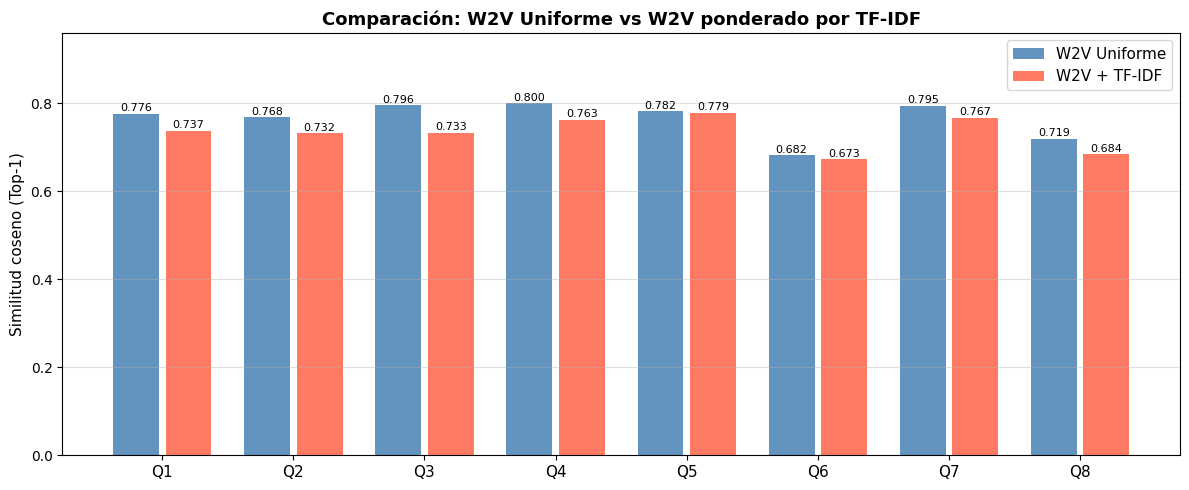

In [23]:
# Gráfico comparativo de similitudes
fig, ax = plt.subplots(figsize=(12, 5))

x          = np.arange(len(QUERIES))
sim_unif   = df_comp["Sim Uniform"].values
sim_tfidf  = df_comp["Sim TF-IDF"].values

b1 = ax.bar(x - 0.2, sim_unif,  width=0.35, label="W2V Uniforme",      color="steelblue", alpha=0.85)
b2 = ax.bar(x + 0.2, sim_tfidf, width=0.35, label="W2V + TF-IDF",      color="tomato",    alpha=0.85)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(list(QUERIES.keys()), fontsize=11)
ax.set_ylabel("Similitud coseno (Top-1)", fontsize=11)
ax.set_title("Comparación: W2V Uniforme vs W2V ponderado por TF-IDF", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylim(0, max(sim_unif.max(), sim_tfidf.max()) * 1.2)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

### 8.2 Visualización de Embeddings con PCA

Se proyectan a 2D los embeddings de las **8 consultas** (★) y sus **Top-3 documentos** recuperados (.), coloreados por consulta. Puntos cercanos = alta similitud semántica.

In [24]:
# Embeddings de las 8 consultas
query_vecs = np.array([process_query(q, wv) for q in QUERIES.values()])

# Embeddings Top-3 por consulta (desde doc_embeddings)
doc_idx_sel, doc_labels_sel, doc_color_idx = [], [], []
for i, (qid, df_res) in enumerate(resultados.items()):
    for _, row in df_res.head(3).iterrows():
        # Recuperar índice en df_corpus desde el ID
        raw_idx = int(row["ID Documento"].split("#")[1])
        doc_idx_sel.append(raw_idx)
        doc_labels_sel.append(str(row["Título Película"])[:22])
        doc_color_idx.append(i)

doc_vecs_sel = doc_embeddings[doc_idx_sel]

# PCA sobre queries + docs seleccionados
todos_vecs = np.vstack([query_vecs, doc_vecs_sel])
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(todos_vecs)

q_coords   = coords_2d[:len(QUERIES)]
doc_coords = coords_2d[len(QUERIES):]

var = pca.explained_variance_ratio_
print(f"Varianza explicada — PC1: {var[0]:.1%} | PC2: {var[1]:.1%} | Total: {sum(var):.1%}")

# Plot
COLORS = plt.cm.tab10(np.linspace(0, 1, 8))
fig, ax = plt.subplots(figsize=(15, 9))

# Documentos
for j, (x, y) in enumerate(doc_coords):
    qi = doc_color_idx[j]
    ax.scatter(x, y, color=COLORS[qi], s=90, marker="o", alpha=0.65, zorder=2)
    ax.annotate(doc_labels_sel[j], (x, y), fontsize=7, alpha=0.8,
                xytext=(4, 4), textcoords="offset points")

# Consultas
for i, (x, y) in enumerate(q_coords):
    ax.scatter(x, y, color=COLORS[i], s=300, marker="*", zorder=4,
               edgecolors="black", linewidths=0.7)
    ax.annotate(list(QUERIES.keys())[i], (x, y), fontsize=12, fontweight="bold",
                xytext=(5, 6), textcoords="offset points", zorder=5)

# Leyenda
handles = [mpatches.Patch(color=COLORS[i],
           label=f"{qid}: {qtxt[:38]}...")
           for i, (qid, qtxt) in enumerate(QUERIES.items())]
ax.legend(handles=handles, loc="upper left", fontsize=8, framealpha=0.9)

ax.set_xlabel(f"PC1 ({var[0]:.1%} varianza)", fontsize=11)
ax.set_ylabel(f"PC2 ({var[1]:.1%} varianza)", fontsize=11)
ax.set_title(
    "Visualización PCA — Espacio de Embeddings Word2Vec\n"
    "★ = Consultas  |  ● = Top-3 documentos recuperados (color por consulta)",
    fontsize=13, fontweight="bold"
)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretación:")
print("  Consultas (★) y sus documentos (●) del mismo color tienden a agruparse,")
print("  evidenciando coherencia semántica del espacio vectorial construido.")

NameError: name 'wv' is not defined